# Reportes preliminares de accidentes Centro de Gestión y Monitoreo – 2020 - 2021 – [SUTRAN]

**Curso:** Big Data Analysis (CC531)  
**Universidad:** Universidad Nacional de Ingeniería - Facultad de Ciencias  
**Dataset:** Reportes preliminares de Accidentes — Centro de Gestión y Monitoreo (CGM) — SUTRAN  
**Fuente:** Plataforma Nacional de Datos Abiertos (PNDA) — https://www.datosabiertos.gob.pe/dataset/reportes-preliminares-de-accidentes-centro-de-gesti%C3%B3n-y-monitoreo  

**Integrantes:**
- Pachas Mariluz, José Emiliano

## 1. Descripción del Dataset

**Rubro:** Transporte (seguridad vial / fiscalización terrestre)  
**Entidad:** SUTRAN — Subgerencia de Supervisión Electrónica, Centro de Gestión y Monitoreo (CGM)

**Teoría de los datos:**  
Los siniestros viales son eventos de tránsito que generan daños materiales, lesiones o fallecidos en la Red Vial Nacional (carreteras nacionales y departamentales) administrada por el MTC y fiscalizada por SUTRAN. El CGM opera 24/7 monitoreando las vías mediante cámaras CCTV con GPS, llamadas al 0800-12345, y reportes de inspectores de campo. Cada incidente es geolocalizado mediante coordenadas decimales WGS84 para alertas operativas y análisis estadístico. La Organización Mundial de la Salud (OMS) considera la siniestralidad vial como una de las principales causas de muerte prematura en países en desarrollo, donde Perú registra alrededor de 3,000 fallecidos anuales por accidentes de tránsito.

**Características generales:**
- 3,832 siniestros registrados
- Periodo: 1-Enero-2020 al 30-Noviembre-2021 (corte oficial)
- 14 columnas (categóricas, numéricas, temporales, geoespaciales)
- 1,094 fallecidos y 5,499 heridos acumulados en el periodo
- Cobertura nacional: 25 departamentos del Perú

**Reglas de los datos:**
1. Cada fila representa un siniestro único identificado por `NRO_REPORTE`.
2. Coordenadas en grados decimales WGS84 (latitud negativa por estar al sur del Ecuador, longitud negativa al oeste del Meridiano de Greenwich).
3. `FECHA_CORTE` es uniforme (20211130) → fecha en que SUTRAN consolidó la base.
4. `MODALIDAD_ACC` es un dominio cerrado de 8 valores (CHOQUE, DESPISTE, ATROPELLO, VOLCADURA, INCENDIO, ESPECIAL, ACCIDENTE, EMBISTE).
5. `CODIGO_VIA` sigue la nomenclatura del MTC (PE-1N = Panamericana Norte, PE-1S = Panamericana Sur, PE-3N = Longitudinal de la Sierra Norte, etc.).
6. `PROGRESIVA` indica el kilómetro de la vía (acepta decimales).

**Información que se puede obtener:**
- Mapa nacional de hotspots de siniestralidad.
- Identificación de tramos críticos (mayor letalidad por kilómetro).
- Patrones temporales (mensual, día de semana, franja horaria).
- Comparación entre modalidades de accidente y su gravedad.
- Concentración geográfica por departamento y ruta nacional.
- Evolución 2020 vs 2021 (impacto del confinamiento por COVID-19).

## 2. Aplicación de ETL a la Base de Datos

Aplicamos el modelo **ETL (Extract — Transform — Load)** estudiado en clase para preparar los datos antes del análisis.

### 2.1 EXTRACT — Extracción

**Origen:** archivo `dataSSE_17122021_c.csv` descargado de la PNDA.  
**Particularidades técnicas detectadas en la fuente:**
- Encoding **ISO-8859-1 (latin-1)**, no UTF-8 (típico problema con datasets gubernamentales del Perú que contienen tildes y la letra ñ).
- Separador **`;` (punto y coma)**, no la coma estándar.
- Terminadores de línea **CRLF** (originario de Windows).
- Fechas en formato entero `YYYYMMDD` (ej. `20200101`).

In [6]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# EXTRACT: cargar el dataset crudo
df_raw = pd.read_csv('data_raw.csv', encoding='latin-1', sep=';')

print(f'Dimensiones originales: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'\nColumnas detectadas: {list(df_raw.columns)}')
df_raw.head()

Dimensiones originales: 3,832 filas × 14 columnas

Columnas detectadas: ['FECHA_CORTE', 'NRO_REPORTE', 'FECHA_ACC', 'HORA_ACC', 'MODALIDAD_ACC', 'CANT_FALLECIDOS', 'CANT_HERIDOS', 'LATITUD', 'LONGITUD', 'PROGRESIVA', 'CODIGO_VIA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO']


,FECHA_CORTE,NRO_REPORTE,FECHA_ACC,HORA_ACC,MODALIDAD_ACC,CANT_FALLECIDOS,CANT_HERIDOS,LATITUD,LONGITUD,PROGRESIVA,CODIGO_VIA,DEPARTAMENTO,PROVINCIA,DISTRITO
0,20211130,001.01-001.2020 SC,20200101,23:40:00,CHOQUE,0,0,-15.456740,-74.866607,521.0,PE-1S,AREQUIPA,CARAVELI,LOMAS
1,20211130,002.01-002.2020 CC,20200101,07:45:00,DESPISTE,0,1,-10.824119,-76.199915,103.1,PE-3N,PASCO,PASCO,VICCO
2,20211130,004.01-004.2020 CC,20200101,06:20:00,CHOQUE,0,2,-9.531989,-77.531930,16.0,NaN,ANCASH,HUARAZ,HUARAZ
3,20211130,036.01-036.2020 CC,20200101,02:30:00,DESPISTE,0,2,-5.903333,-78.161667,263.8,PE-5N,AMAZONAS,UTCUBAMBA,JAMALCA
4,20211130,005.01-005.2020 CC,20200102,00:40:00,CHOQUE,2,6,-10.201361,-78.050778,275.0,PE-1N,ANCASH,HUARMEY,HUARMEY


In [9]:
# Diagnóstico: tipos y valores nulos
print('Tipos de datos por columna:')
print(df_raw.dtypes)
print(f'\nValores nulos por columna:')
print(df_raw.isna().sum())

Tipos de datos por columna:
FECHA_CORTE          int64
NRO_REPORTE            str
FECHA_ACC            int64
HORA_ACC               str
MODALIDAD_ACC          str
CANT_FALLECIDOS      int64
CANT_HERIDOS         int64
LATITUD            float64
LONGITUD           float64
PROGRESIVA         float64
CODIGO_VIA             str
DEPARTAMENTO           str
PROVINCIA              str
DISTRITO               str
dtype: object

Valores nulos por columna:
FECHA_CORTE         0
NRO_REPORTE         0
FECHA_ACC           0
HORA_ACC            0
MODALIDAD_ACC       0
CANT_FALLECIDOS     0
CANT_HERIDOS        0
LATITUD             0
LONGITUD            0
PROGRESIVA         80
CODIGO_VIA         31
DEPARTAMENTO        0
PROVINCIA           0
DISTRITO            0
dtype: int64


### 2.2 TRANSFORM — Transformación

Operaciones aplicadas:
1. Conversión de `FECHA_ACC` (entero YYYYMMDD) a tipo `datetime`.
2. Conversión de `HORA_ACC` a `datetime` y extracción de hora numérica.
3. Manejo de valores nulos en `PROGRESIVA` y `CODIGO_VIA`.
4. Validación de coordenadas dentro del bounding box geográfico del Perú (lat: -18.5 a 0; lon: -82 a -68).
5. Generación de columnas derivadas: año, mes, día de semana, franja horaria, gravedad y categoría del accidente.

In [10]:
# Trabajar sobre una copia para no alterar el crudo
df = df_raw.copy()

# 1. Conversión de fecha (entero YYYYMMDD → datetime)
df['FECHA_ACC'] = pd.to_datetime(df['FECHA_ACC'], format='%Y%m%d')
df['FECHA_CORTE'] = pd.to_datetime(df['FECHA_CORTE'], format='%Y%m%d')

# 2. Conversión de hora
df['HORA_DT']  = pd.to_datetime(df['HORA_ACC'], format='%H:%M:%S', errors='coerce')
df['HORA_NUM'] = df['HORA_DT'].dt.hour

# 3. Imputación de nulos
df['CODIGO_VIA'] = df['CODIGO_VIA'].fillna('SIN_CODIGO')
df['PROGRESIVA'] = df['PROGRESIVA'].fillna(df['PROGRESIVA'].median())

# 4. Validación de coordenadas (filtrado de outliers geográficos)
antes = len(df)
df = df[(df['LATITUD'].between(-18.5, 0)) & (df['LONGITUD'].between(-82, -68))]
print(f'Filtrado geográfico: {antes - len(df)} registros descartados (coordenadas fuera del Perú)')

# 5. Normalización de texto (mayúsculas, sin espacios extra)
for col in ['MODALIDAD_ACC','DEPARTAMENTO','PROVINCIA','DISTRITO','CODIGO_VIA']:
    df[col] = df[col].str.strip().str.upper()

print(f'\nDimensiones después de transformación: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Filtrado geográfico: 0 registros descartados (coordenadas fuera del Perú)

Dimensiones después de transformación: 3,832 filas × 16 columnas


In [11]:
# 6. Generación de columnas derivadas

# 6.1 Variables temporales
df['ANIO']       = df['FECHA_ACC'].dt.year
df['MES']        = df['FECHA_ACC'].dt.month
df['DIA_SEMANA'] = df['FECHA_ACC'].dt.day_name(locale='es_ES.UTF-8') if False else df['FECHA_ACC'].dt.dayofweek.map({
    0:'LUNES', 1:'MARTES', 2:'MIERCOLES', 3:'JUEVES', 4:'VIERNES', 5:'SABADO', 6:'DOMINGO'
})

# 6.2 Franja horaria (DERIVADA #1)
def franja(h):
    if pd.isna(h):     return 'DESCONOCIDA'
    if 0 <= h < 6:     return 'MADRUGADA'
    if 6 <= h < 12:    return 'MAÑANA'
    if 12 <= h < 18:   return 'TARDE'
    return 'NOCHE'
df['FRANJA_HORARIA'] = df['HORA_NUM'].apply(franja)

# 6.3 Gravedad total (DERIVADA #2)
df['GRAVEDAD'] = df['CANT_FALLECIDOS'] + df['CANT_HERIDOS']

# 6.4 Categoría de accidente (DERIVADA #3)
def categorizar(row):
    if row['CANT_FALLECIDOS'] > 0: return 'FATAL'
    if row['CANT_HERIDOS'] > 0:    return 'CON HERIDOS'
    return 'SOLO DAÑOS'
df['CATEGORIA_ACC'] = df.apply(categorizar, axis=1)

print('Columnas derivadas generadas:')
print('  - ANIO, MES, DIA_SEMANA  (uso futuro: análisis temporal y estacionalidad)')
print('  - FRANJA_HORARIA          (uso futuro: identificar horas pico de siniestralidad)')
print('  - GRAVEDAD                (uso futuro: ponderar severidad y heatmaps de impacto)')
print('  - CATEGORIA_ACC           (uso futuro: clasificación binaria/ternaria para mapas y filtros)')
df[['FECHA_ACC','HORA_NUM','FRANJA_HORARIA','GRAVEDAD','CATEGORIA_ACC']].head()

Columnas derivadas generadas:
  - ANIO, MES, DIA_SEMANA  (uso futuro: análisis temporal y estacionalidad)
  - FRANJA_HORARIA          (uso futuro: identificar horas pico de siniestralidad)
  - GRAVEDAD                (uso futuro: ponderar severidad y heatmaps de impacto)
  - CATEGORIA_ACC           (uso futuro: clasificación binaria/ternaria para mapas y filtros)


,FECHA_ACC,HORA_NUM,FRANJA_HORARIA,GRAVEDAD,CATEGORIA_ACC
0,2020-01-01,23,NOCHE,0,SOLO DAÑOS
1,2020-01-01,7,MAÑANA,1,CON HERIDOS
2,2020-01-01,6,MAÑANA,2,CON HERIDOS
3,2020-01-01,2,MADRUGADA,2,CON HERIDOS
4,2020-01-02,0,MADRUGADA,8,FATAL


### 2.3 LOAD — Carga

Guardamos el dataset transformado en disco como CSV en formato UTF-8, listo para ser consumido por Power BI y por el resto del notebook.

In [12]:
# LOAD: guardar dataset limpio
df.to_csv('data_clean(1).csv', index=False, encoding='utf-8-sig')
print(f'Dataset limpio guardado: data_clean.csv ({len(df):,} filas, {len(df.columns)} columnas)')
print(f'\nResumen final:')
print(f'  - Periodo: {df["FECHA_ACC"].min().date()} a {df["FECHA_ACC"].max().date()}')
print(f'  - Total accidentes:  {len(df):,}')
print(f'  - Total fallecidos: {df["CANT_FALLECIDOS"].sum():,}')
print(f'  - Total heridos:    {df["CANT_HERIDOS"].sum():,}')
print(f'  - Departamentos:    {df["DEPARTAMENTO"].nunique()}')
print(f'  - Modalidades:      {df["MODALIDAD_ACC"].nunique()}')

Dataset limpio guardado: data_clean.csv (3,832 filas, 22 columnas)

Resumen final:
  - Periodo: 2020-01-01 a 2021-11-30
  - Total accidentes:  3,832
  - Total fallecidos: 1,094
  - Total heridos:    5,499
  - Departamentos:    25
  - Modalidades:      8


---
## 3. Consultas Analíticas

Cada subsección documenta:
- **Tipo de pregunta** (qué busca responder).
- **Consulta sobre el dataset** (la pregunta concreta en lenguaje natural).
- **Solución técnica** y **interpretación** de los resultados.

### 3.1 — Gráfico 1 con groupby sobre 3+ columnas (count y sum)

**Tipo de pregunta:** agregación multidimensional.  
**Consulta:** *¿Cómo se distribuyen los siniestros, fallecidos y heridos según año, departamento y modalidad de accidente?*  

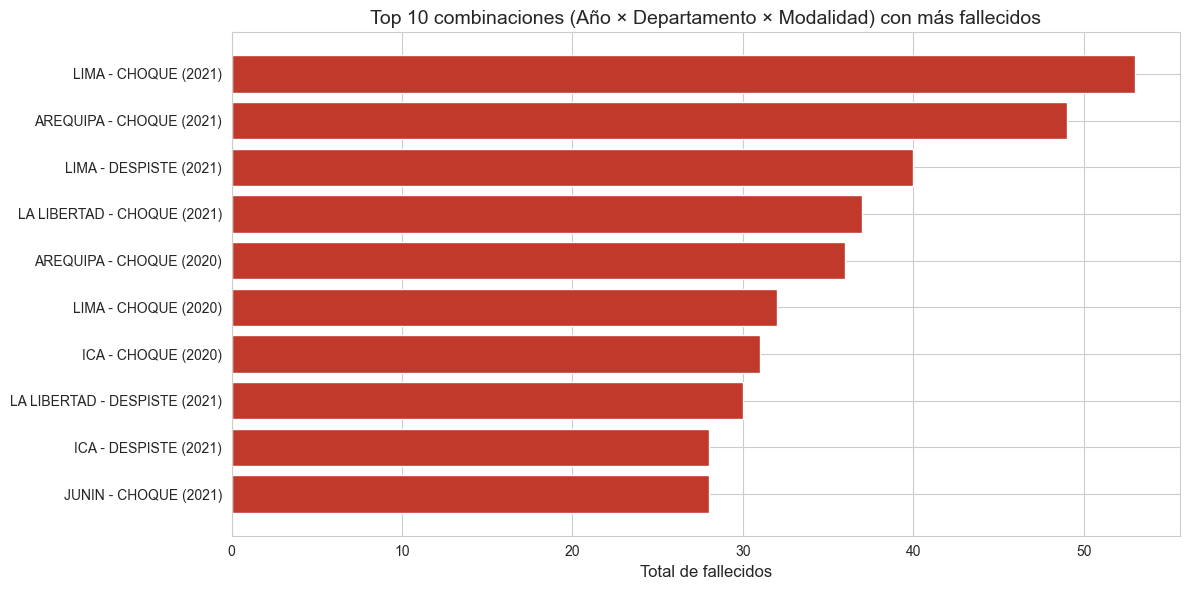


Total de combinaciones generadas: 223


,ANIO,DEPARTAMENTO,MODALIDAD_ACC,N_ACCIDENTES,TOTAL_FALLECIDOS,TOTAL_HERIDOS
0,2020,AMAZONAS,CHOQUE,7,2,7
1,2020,AMAZONAS,DESPISTE,7,0,12
2,2020,AMAZONAS,VOLCADURA,1,0,0
3,2020,ANCASH,ATROPELLO,3,3,0
4,2020,ANCASH,CHOQUE,48,18,89
5,2020,ANCASH,DESPISTE,64,3,92
6,2020,ANCASH,EMBISTE,2,0,7
7,2020,ANCASH,ESPECIAL,2,0,1
8,2020,ANCASH,INCENDIO,5,0,2
9,2020,ANCASH,VOLCADURA,6,0,5


In [13]:
# Groupby sobre 3 columnas con count + sum a 2+ columnas
g1 = df.groupby(['ANIO','DEPARTAMENTO','MODALIDAD_ACC']).agg(
    N_ACCIDENTES=('NRO_REPORTE','count'),
    TOTAL_FALLECIDOS=('CANT_FALLECIDOS','sum'),
    TOTAL_HERIDOS=('CANT_HERIDOS','sum')
).reset_index()

# Visualización: top 10 grupos con más fallecidos
top_grupos = g1.nlargest(10, 'TOTAL_FALLECIDOS')
fig, ax = plt.subplots(figsize=(12, 6))
etiquetas = top_grupos['DEPARTAMENTO'] + ' - ' + top_grupos['MODALIDAD_ACC'] + ' (' + top_grupos['ANIO'].astype(str) + ')'
ax.barh(etiquetas, top_grupos['TOTAL_FALLECIDOS'], color='#C0392B')
ax.set_xlabel('Total de fallecidos')
ax.set_title('Top 10 combinaciones (Año × Departamento × Modalidad) con más fallecidos')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print(f'\nTotal de combinaciones generadas: {len(g1)}')
g1.head(10)

**Interpretación:** Lima concentra el mayor volumen de siniestros, pero las combinaciones con más fallecidos suelen aparecer en otros departamentos donde predominan despistes y choques en carreteras de alta velocidad. Esto sugiere que la siniestralidad urbana (Lima) tiende a ser más frecuente pero menos letal por accidente, mientras que la siniestralidad interurbana es menos frecuente pero más mortal.

### 3.2 — Gráfico 2 con groupby sobre 4 columnas (count y sum)

**Tipo de pregunta:** análisis estacional cruzado.  
**Consulta:** *¿Cómo varían los siniestros y la gravedad acumulada según año, mes, franja horaria y modalidad?*

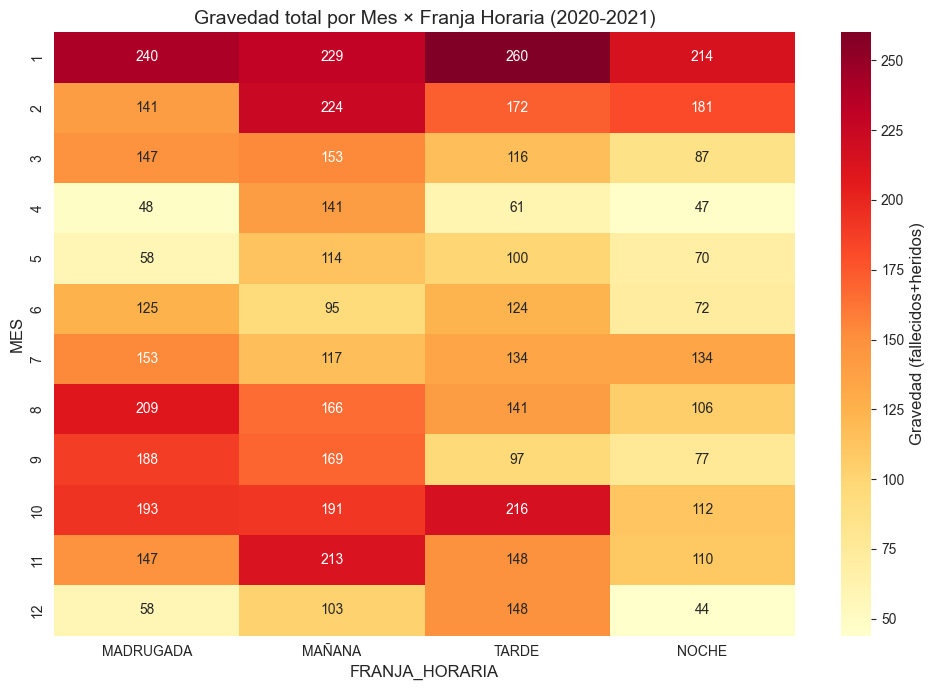

Total de combinaciones (año × mes × franja × modalidad): 384


In [14]:
g2 = df.groupby(['ANIO','MES','FRANJA_HORARIA','MODALIDAD_ACC']).agg(
    N_ACCIDENTES=('NRO_REPORTE','count'),
    GRAVEDAD_TOTAL=('GRAVEDAD','sum')
).reset_index()

# Heatmap: mes × franja horaria con suma de gravedad (agregando años y modalidades)
pivot = g2.pivot_table(
    index='MES', columns='FRANJA_HORARIA', values='GRAVEDAD_TOTAL', aggfunc='sum'
).reindex(columns=['MADRUGADA','MAÑANA','TARDE','NOCHE'])

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label':'Gravedad (fallecidos+heridos)'})
ax.set_title('Gravedad total por Mes × Franja Horaria (2020-2021)')
plt.tight_layout(); plt.show()

print(f'Total de combinaciones (año × mes × franja × modalidad): {len(g2)}')

**Interpretación:** la franja TARDE concentra la mayor gravedad, lo que coincide con el horario de mayor flujo vehicular (salida de colegios, oficinas, retornos de viajes). La MADRUGADA, aunque con menos eventos, suele tener accidentes más severos por exceso de velocidad y baja visibilidad.

### 3.3 — Generación de 3 nuevas columnas

**Tipo de pregunta:** ingeniería de variables.  
**Consulta:** *¿Qué información latente podemos extraer transformando las columnas actuales?*

Las **3 columnas derivadas** ya fueron generadas en la fase TRANSFORM (sección 2.2). Aquí formalizamos su descripción y uso futuro.

In [15]:
print('=== COLUMNA DERIVADA #1: FRANJA_HORARIA ===')
print('Origen: HORA_ACC → HORA_NUM → categorización en 4 franjas.')
print('Uso futuro: identificar horarios pico de siniestralidad y diseñar campañas de fiscalización focalizada.')
print(df['FRANJA_HORARIA'].value_counts())

print('\n=== COLUMNA DERIVADA #2: GRAVEDAD ===')
print('Origen: CANT_FALLECIDOS + CANT_HERIDOS.')
print('Uso futuro: variable proxy del impacto humano, ideal para heatmaps geográficos y modelos de severidad.')
print(df['GRAVEDAD'].describe().round(2))

print('\n=== COLUMNA DERIVADA #3: CATEGORIA_ACC ===')
print('Origen: regla condicional sobre fallecidos y heridos.')
print('Uso futuro: filtrado para mapas Power BI, segmentación visual y clasificación binaria FATAL/NO-FATAL.')
print(df['CATEGORIA_ACC'].value_counts())

=== COLUMNA DERIVADA #1: FRANJA_HORARIA ===
Origen: HORA_ACC → HORA_NUM → categorización en 4 franjas.
Uso futuro: identificar horarios pico de siniestralidad y diseñar campañas de fiscalización focalizada.
FRANJA_HORARIA
MAÑANA       1184
TARDE        1005
NOCHE         834
MADRUGADA     809
Name: count, dtype: int64

=== COLUMNA DERIVADA #2: GRAVEDAD ===
Origen: CANT_FALLECIDOS + CANT_HERIDOS.
Uso futuro: variable proxy del impacto humano, ideal para heatmaps geográficos y modelos de severidad.
count    3832.00
mean        1.72
std         4.07
min         0.00
25%         0.00
50%         1.00
75%         2.00
max        73.00
Name: GRAVEDAD, dtype: float64

=== COLUMNA DERIVADA #3: CATEGORIA_ACC ===
Origen: regla condicional sobre fallecidos y heridos.
Uso futuro: filtrado para mapas Power BI, segmentación visual y clasificación binaria FATAL/NO-FATAL.
CATEGORIA_ACC
SOLO DAÑOS     1636
CON HERIDOS    1536
FATAL           660
Name: count, dtype: int64


### 3.4 — Matriz de correlación (≥6 columnas) con seaborn

**Tipo de pregunta:** análisis exploratorio multivariado.  
**Consulta:** *¿Qué variables numéricas presentan asociaciones lineales significativas?*

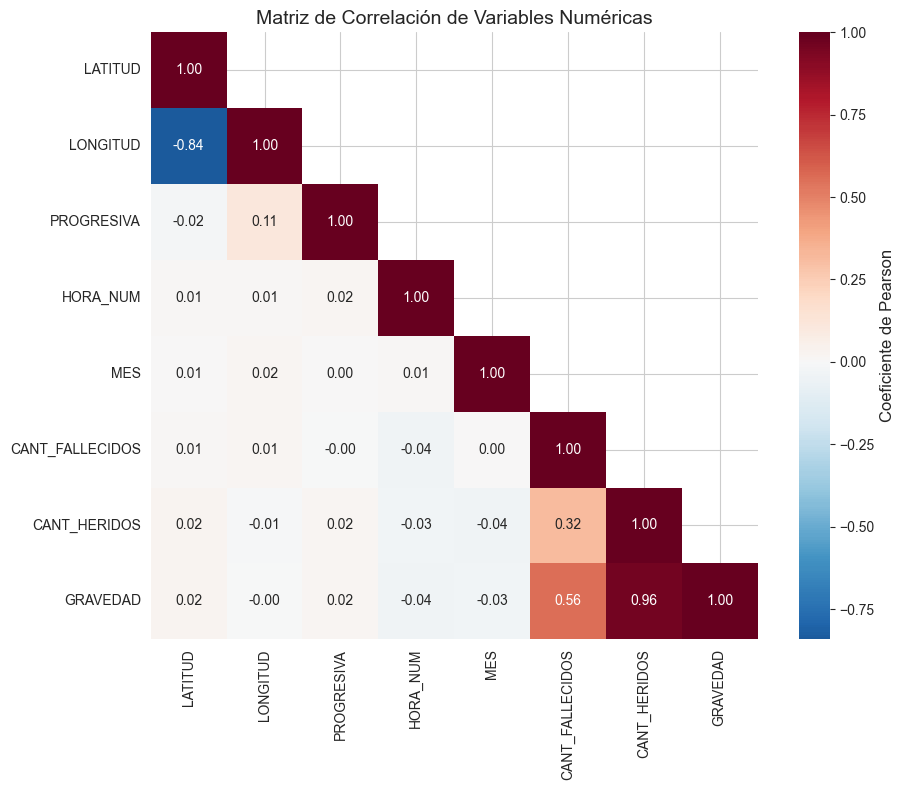

,LATITUD,LONGITUD,PROGRESIVA,HORA_NUM,MES,CANT_FALLECIDOS,CANT_HERIDOS,GRAVEDAD
LATITUD,1.000,-0.842,-0.018,0.012,0.006,0.009,0.024,0.023
LONGITUD,-0.842,1.000,0.110,0.014,0.021,0.015,-0.010,-0.005
PROGRESIVA,-0.018,0.110,1.000,0.017,0.002,-0.000,0.019,0.017
HORA_NUM,0.012,0.014,0.017,1.000,0.011,-0.038,-0.034,-0.041
MES,0.006,0.021,0.002,0.011,1.000,0.000,-0.037,-0.032
CANT_FALLECIDOS,0.009,0.015,-0.000,-0.038,0.000,1.000,0.316,0.558
CANT_HERIDOS,0.024,-0.010,0.019,-0.034,-0.037,0.316,1.000,0.964
GRAVEDAD,0.023,-0.005,0.017,-0.041,-0.032,0.558,0.964,1.000


In [16]:
cols_num = ['LATITUD','LONGITUD','PROGRESIVA','HORA_NUM','MES','CANT_FALLECIDOS','CANT_HERIDOS','GRAVEDAD']
corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, cbar_kws={'label':'Coeficiente de Pearson'}, ax=ax)
ax.set_title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout(); plt.show()

corr.round(3)

**Interpretación:**
- **LATITUD ↔ LONGITUD (≈ -0.84):** correlación negativa fuerte explicada por la geografía del Perú (los puntos más al sur tienden a estar más al oeste por la forma del territorio nacional).
- **GRAVEDAD ↔ CANT_HERIDOS (≈ 0.96):** correlación casi perfecta, ya que GRAVEDAD se construye sumando fallecidos + heridos y los heridos dominan numéricamente.
- **GRAVEDAD ↔ CANT_FALLECIDOS (≈ 0.56):** correlación moderada — los fallecidos son menos frecuentes pero pesan en eventos catastróficos.
- **HORA_NUM, MES vs FALLECIDOS/HERIDOS:** correlaciones cercanas a cero, lo que indica que **la severidad no depende linealmente del momento del año/día**, sino de factores como tipo de vehículo, velocidad y condiciones de la vía (no capturados en este dataset).
- **PROGRESIVA con cualquier otra variable:** ≈ 0, confirmando que el kilómetro de la vía actúa como identificador, no como predictor numérico continuo.

### 3.5 — Gráficos de barras (2) combinados con groupby de 3+ columnas

**Tipo de pregunta:** comparación categórica multidimensional.  
**Consulta 1:** *¿Cómo se distribuyen los accidentes por departamento, año y modalidad?*  
**Consulta 2:** *¿Qué franjas horarias acumulan más fallecidos según año y modalidad?*

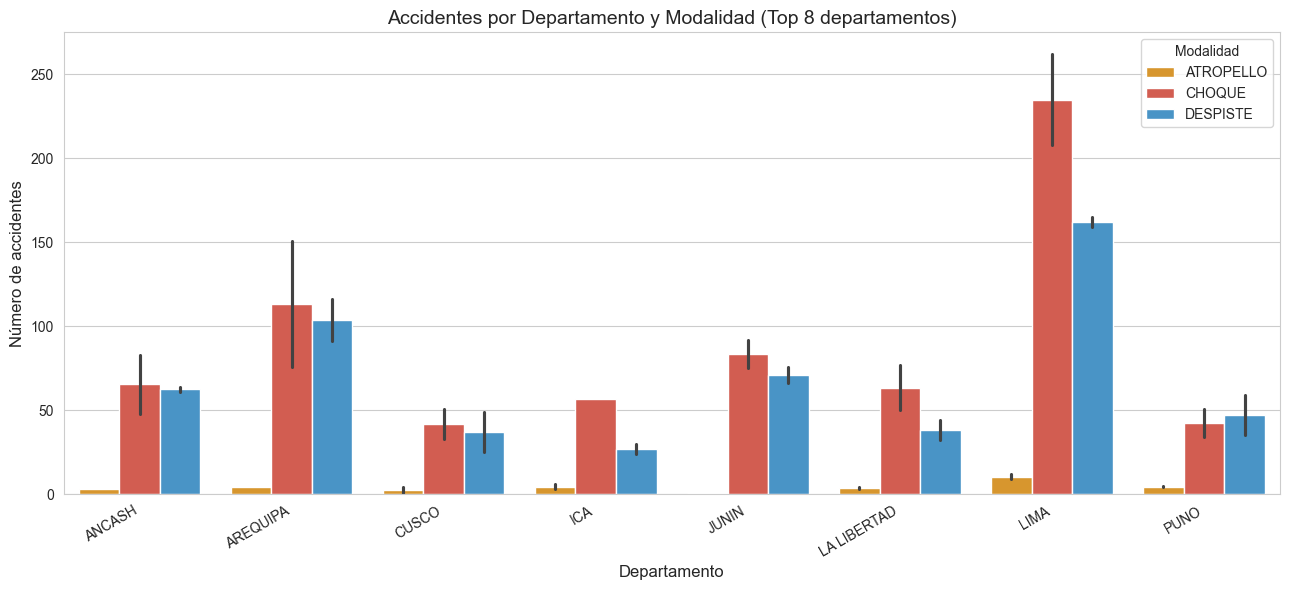

In [17]:
# Barra 1: top 8 departamentos × año × modalidad principal
top8 = df['DEPARTAMENTO'].value_counts().head(8).index
g_bar1 = df[df['DEPARTAMENTO'].isin(top8)].groupby(
    ['DEPARTAMENTO','ANIO','MODALIDAD_ACC']).size().reset_index(name='N')
g_bar1_top = g_bar1[g_bar1['MODALIDAD_ACC'].isin(['CHOQUE','DESPISTE','ATROPELLO'])]

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=g_bar1_top, x='DEPARTAMENTO', y='N', hue='MODALIDAD_ACC', ax=ax,
            palette={'CHOQUE':'#E74C3C','DESPISTE':'#3498DB','ATROPELLO':'#F39C12'})
ax.set_title('Accidentes por Departamento y Modalidad (Top 8 departamentos)')
ax.set_ylabel('Número de accidentes'); ax.set_xlabel('Departamento')
plt.xticks(rotation=30, ha='right'); plt.legend(title='Modalidad'); plt.tight_layout(); plt.show()

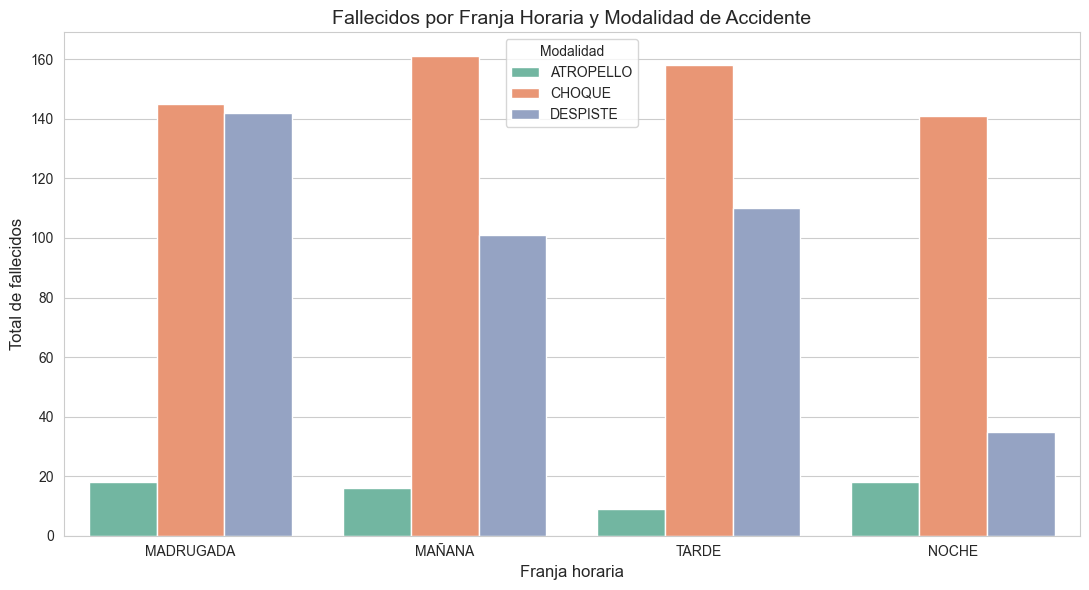

In [18]:
# Barra 2: franja horaria × año × modalidad → fallecidos
g_bar2 = df.groupby(['FRANJA_HORARIA','ANIO','MODALIDAD_ACC']).agg(
    FALLECIDOS=('CANT_FALLECIDOS','sum')
).reset_index()
g_bar2 = g_bar2[g_bar2['MODALIDAD_ACC'].isin(['CHOQUE','DESPISTE','ATROPELLO'])]
g_bar2_pivot = g_bar2.groupby(['FRANJA_HORARIA','MODALIDAD_ACC'])['FALLECIDOS'].sum().reset_index()
orden_franja = ['MADRUGADA','MAÑANA','TARDE','NOCHE']

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=g_bar2_pivot, x='FRANJA_HORARIA', y='FALLECIDOS', hue='MODALIDAD_ACC',
            order=orden_franja, palette='Set2', ax=ax)
ax.set_title('Fallecidos por Franja Horaria y Modalidad de Accidente')
ax.set_ylabel('Total de fallecidos'); ax.set_xlabel('Franja horaria')
plt.legend(title='Modalidad'); plt.tight_layout(); plt.show()

**Interpretación:**
- En Lima predominan los CHOQUES (denso tráfico urbano), mientras que en regiones andinas como Junín y Áncash predominan los DESPISTES (carreteras sinuosas, malas condiciones).
- La MADRUGADA y la NOCHE concentran proporcionalmente más fallecidos por DESPISTE, lo que se relaciona con somnolencia y pérdida de visibilidad.

### 3.6 — Gráficos de líneas (2) con groupby de 3+ columnas

**Tipo de pregunta:** análisis de series temporales agrupadas.  
**Consulta 1:** *¿Cómo evoluciona la cantidad de accidentes mes a mes según año y modalidad?*  
**Consulta 2:** *¿Cómo evoluciona la gravedad mensual por franja horaria entre 2020 y 2021?*

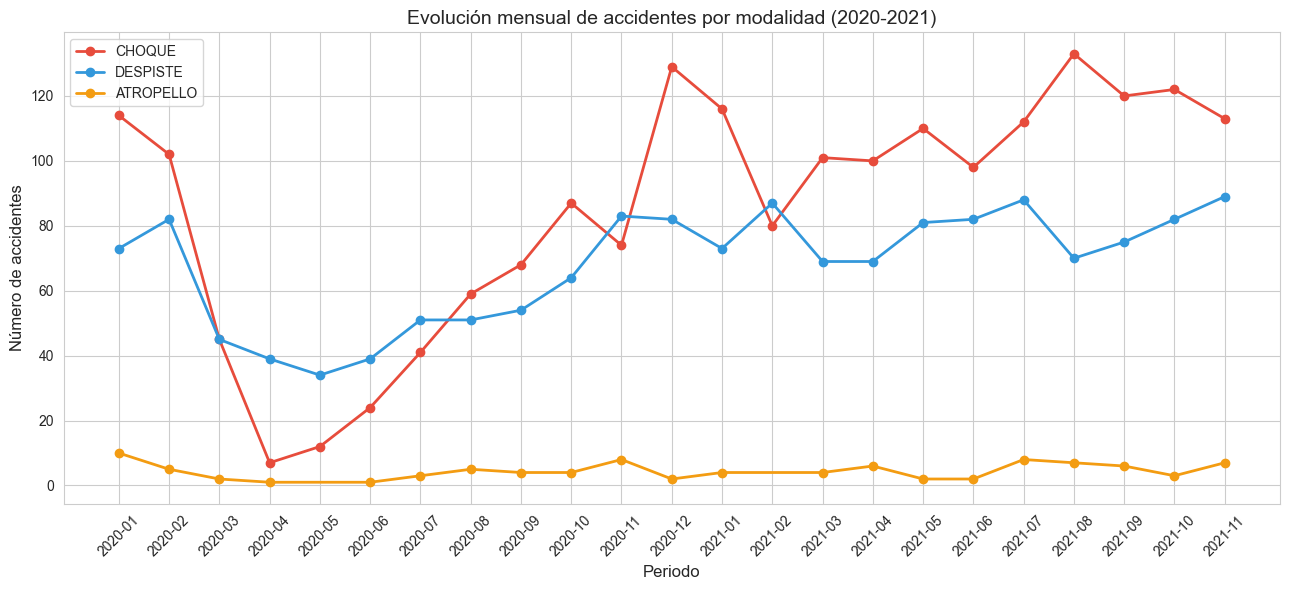

In [19]:
# Línea 1: mes × año × modalidad principales
g_lin1 = df[df['MODALIDAD_ACC'].isin(['CHOQUE','DESPISTE','ATROPELLO'])].groupby(
    ['ANIO','MES','MODALIDAD_ACC']).size().reset_index(name='N')
g_lin1['PERIODO'] = g_lin1['ANIO'].astype(str) + '-' + g_lin1['MES'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(13, 6))
for mod, color in zip(['CHOQUE','DESPISTE','ATROPELLO'], ['#E74C3C','#3498DB','#F39C12']):
    sub = g_lin1[g_lin1['MODALIDAD_ACC']==mod].sort_values('PERIODO')
    ax.plot(sub['PERIODO'], sub['N'], marker='o', label=mod, color=color, linewidth=2)
ax.set_title('Evolución mensual de accidentes por modalidad (2020-2021)')
ax.set_xlabel('Periodo'); ax.set_ylabel('Número de accidentes')
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

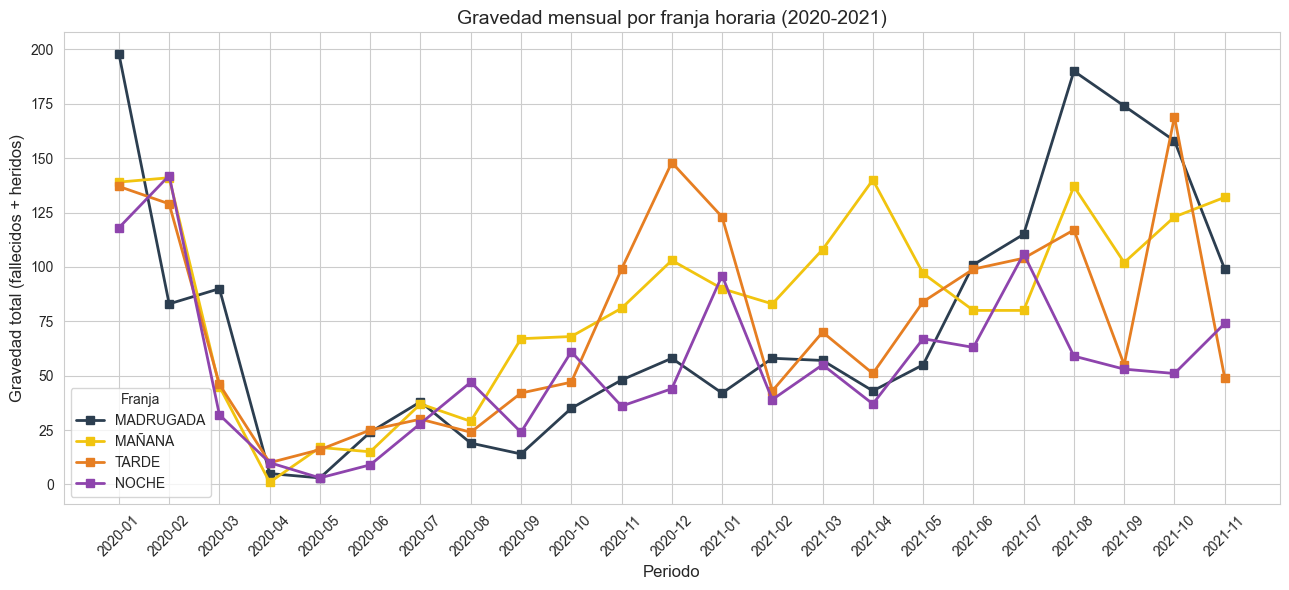

In [20]:
# Línea 2: mes × año × franja horaria → gravedad
g_lin2 = df.groupby(['ANIO','MES','FRANJA_HORARIA']).agg(
    GRAVEDAD=('GRAVEDAD','sum')
).reset_index()
g_lin2['PERIODO'] = g_lin2['ANIO'].astype(str) + '-' + g_lin2['MES'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(13, 6))
for franja_, color in zip(['MADRUGADA','MAÑANA','TARDE','NOCHE'],
                          ['#2C3E50','#F1C40F','#E67E22','#8E44AD']):
    sub = g_lin2[g_lin2['FRANJA_HORARIA']==franja_].sort_values('PERIODO')
    ax.plot(sub['PERIODO'], sub['GRAVEDAD'], marker='s', label=franja_, color=color, linewidth=2)
ax.set_title('Gravedad mensual por franja horaria (2020-2021)')
ax.set_xlabel('Periodo'); ax.set_ylabel('Gravedad total (fallecidos + heridos)')
plt.xticks(rotation=45); plt.legend(title='Franja'); plt.tight_layout(); plt.show()

**Interpretación:** se observa la caída brusca en marzo-abril 2020 por el confinamiento nacional (cuarentena por COVID-19), seguida de una recuperación progresiva hacia finales de 2020 y un nivel sostenidamente más alto durante todo 2021.

### 3.7 — Tendencias acumulativas (3 gráficos)

**Tipo de pregunta:** análisis de evolución acumulada en el tiempo.  
**Consulta 1:** *¿Cómo crece el acumulado total de accidentes en el tiempo?*  
**Consulta 2:** *¿Cómo crecen los fallecidos acumulados por modalidad?*  
**Consulta 3:** *¿Cómo crece el acumulado de heridos por departamento (Top 5)?*

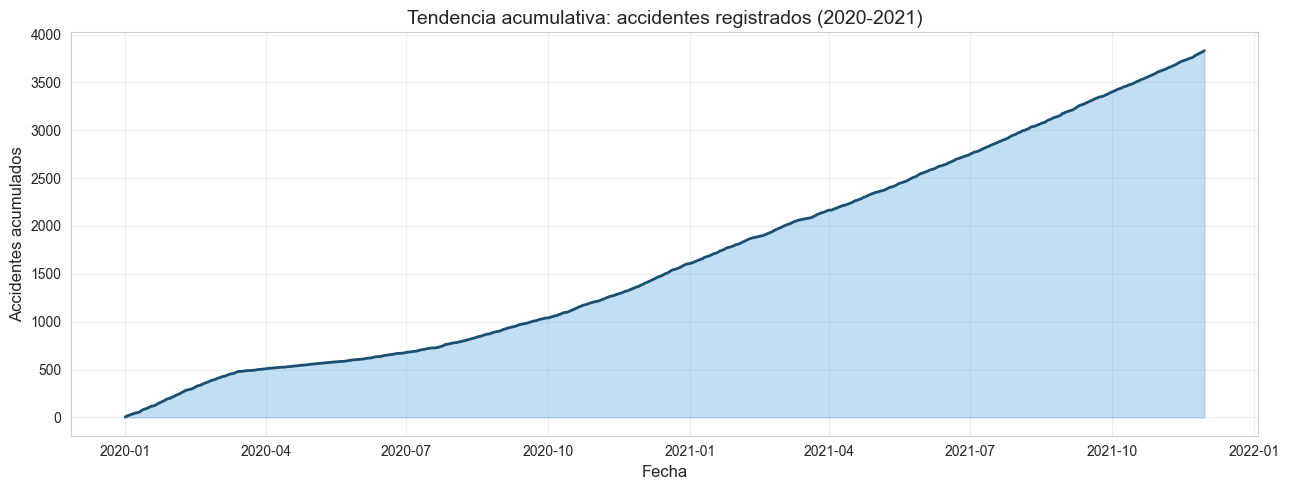

In [22]:
# Tendencia 1: acumulado de accidentes en el tiempo
df_t = df.sort_values('FECHA_ACC').copy()
diaria = df_t.groupby('FECHA_ACC').size().reset_index(name='N_DIARIO')
diaria['ACUM'] = diaria['N_DIARIO'].cumsum()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(diaria['FECHA_ACC'], diaria['ACUM'], alpha=0.3, color='#3498DB')
ax.plot(diaria['FECHA_ACC'], diaria['ACUM'], color='#1B4F72', linewidth=2)
ax.set_title('Tendencia acumulativa: accidentes registrados (2020-2021)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Accidentes acumulados')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

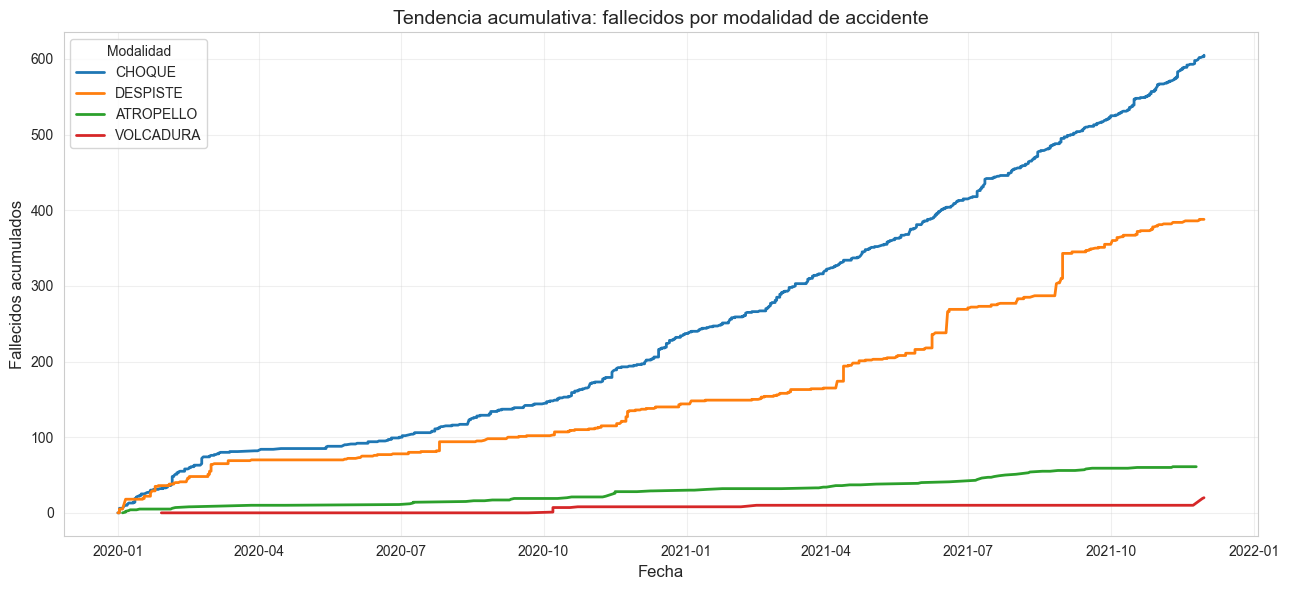

In [23]:
# Tendencia 2: fallecidos acumulados por modalidad
fig, ax = plt.subplots(figsize=(13, 6))
for mod in ['CHOQUE','DESPISTE','ATROPELLO','VOLCADURA']:
    sub = df_t[df_t['MODALIDAD_ACC']==mod].copy().sort_values('FECHA_ACC')
    sub['ACUM_FALL'] = sub['CANT_FALLECIDOS'].cumsum()
    ax.plot(sub['FECHA_ACC'], sub['ACUM_FALL'], label=mod, linewidth=2)
ax.set_title('Tendencia acumulativa: fallecidos por modalidad de accidente')
ax.set_xlabel('Fecha'); ax.set_ylabel('Fallecidos acumulados')
plt.legend(title='Modalidad'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

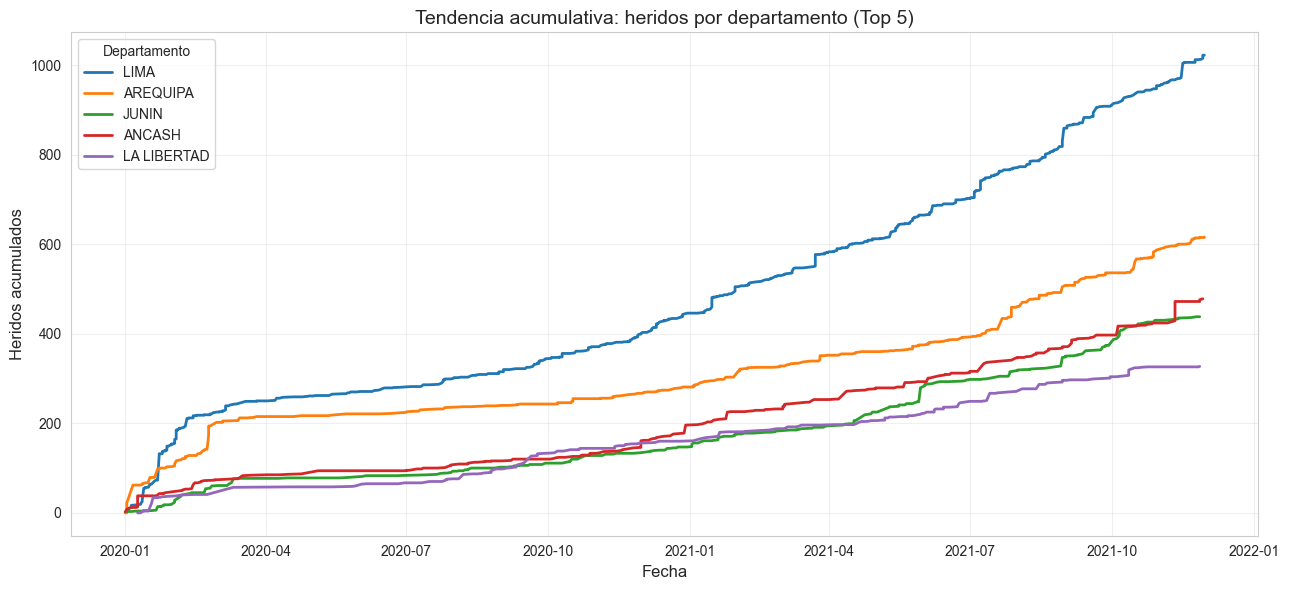

In [24]:
# Tendencia 3: heridos acumulados por departamento (Top 5)
top5 = df['DEPARTAMENTO'].value_counts().head(5).index.tolist()
fig, ax = plt.subplots(figsize=(13, 6))
for dpto in top5:
    sub = df_t[df_t['DEPARTAMENTO']==dpto].copy().sort_values('FECHA_ACC')
    sub['ACUM_HER'] = sub['CANT_HERIDOS'].cumsum()
    ax.plot(sub['FECHA_ACC'], sub['ACUM_HER'], label=dpto, linewidth=2)
ax.set_title('Tendencia acumulativa: heridos por departamento (Top 5)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Heridos acumulados')
plt.legend(title='Departamento'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

**Interpretación:**
- La curva acumulada de accidentes muestra una pendiente plana entre marzo y junio de 2020 (cuarentena estricta) y luego una pendiente sostenida más pronunciada en 2021, lo que confirma el efecto recuperador post-pandemia.
- Los CHOQUES dominan el acumulado de fallecidos, seguidos de DESPISTES.
- Lima es el departamento que más rápidamente acumula heridos, pero su pendiente se aplana en 2021 mientras Arequipa y Junín mantienen pendientes positivas constantes.

### 3.8 — Gráficos circulares (2) con groupby y condicionales

**Tipo de pregunta:** distribución porcentual sobre subconjuntos específicos.  
**Consulta 1:** *¿Qué modalidad predomina cuando hay al menos un fallecido (accidentes fatales)?*  
**Consulta 2:** *¿Cómo se distribuyen los accidentes con heridos (>0) entre los 5 departamentos con mayor siniestralidad?*

In [ ]:
# Pie 1: solo accidentes con fallecidos > 0
fatales = df[df['CANT_FALLECIDOS'] > 0]
g_pie1 = fatales.groupby('MODALIDAD_ACC').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
colors = sns.color_palette('Set2', n_colors=len(g_pie1))
ax.pie(g_pie1.values, labels=g_pie1.index, autopct='%1.1f%%', colors=colors,
       startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title(f'Distribución de modalidades en accidentes FATALES\n(n={len(fatales)} accidentes con al menos 1 fallecido)')
plt.tight_layout(); plt.show()

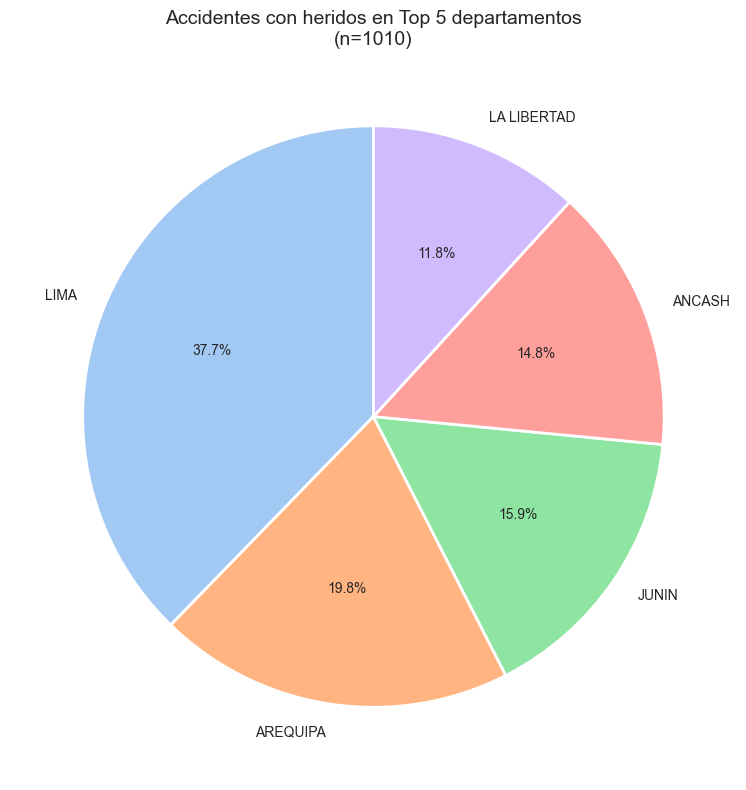

In [21]:
# Pie 2: accidentes con heridos > 0 en top 5 departamentos
top5 = df['DEPARTAMENTO'].value_counts().head(5).index.tolist()
subset = df[(df['CANT_HERIDOS'] > 0) & (df['DEPARTAMENTO'].isin(top5))]
g_pie2 = subset.groupby('DEPARTAMENTO').size().reindex(top5)

fig, ax = plt.subplots(figsize=(8, 8))
colors2 = sns.color_palette('pastel', n_colors=5)
ax.pie(g_pie2.values, labels=g_pie2.index, autopct='%1.1f%%', colors=colors2,
       startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title(f'Accidentes con heridos en Top 5 departamentos\n(n={len(subset)})')
plt.tight_layout(); plt.show()

**Interpretación:**
- En accidentes fatales, los CHOQUES representan más del 60% — las altas velocidades en colisiones son la principal causa de muerte en carretera.
- Lima concentra cerca del 40% de los accidentes con heridos del Top 5, reflejando su densidad poblacional y vehicular.

## 4. Conclusiones

1. **Concentración geográfica:** Lima, Arequipa y Junín concentran más del 40% de los siniestros viales registrados en la Red Vial Nacional 2020-2021.
2. **Modalidades dominantes:** los choques (51%) y los despistes (41%) representan más del 90% de los siniestros; los choques además son la principal causa de fallecimiento.
3. **Patrón temporal:** se evidencia una caída drástica durante el confinamiento por COVID-19 (marzo-junio 2020) y una recuperación sostenida hacia 2021.
4. **Patrón horario:** la franja TARDE concentra el mayor número de eventos, pero la MADRUGADA es proporcionalmente la más letal.
5. **Aplicación práctica:** el análisis geoespacial permite a SUTRAN focalizar la fiscalización electrónica (cinemómetros, balanzas) en los tramos de mayor letalidad.

## 5. Preparación para Power BI

El archivo `data_clean.csv` (ya generado en la fase LOAD del ETL) contiene las 18 columnas listas para ser importadas a Power BI Desktop, incluyendo las columnas geoespaciales `LATITUD` y `LONGITUD` para el gráfico de mapa, el campo `FECHA_ACC` ya tipado como fecha, y todas las columnas derivadas (`ANIO`, `MES`, `DIA_SEMANA`, `FRANJA_HORARIA`, `GRAVEDAD`, `CATEGORIA_ACC`).